In [63]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns


In [64]:
df = pd.read_csv("car_data.csv")

##2. Summary and Basic Statistics
🔹 check Top 5 rows:


In [65]:
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner


## 📊 1. Data Cleaning and Formatting
Sabse pehle data ko readable aur clean banana zaroori hai.

🔹 a. Column names ko readable banao:


In [66]:
df.columns = ["Car Name","Year","Selling Price","Kilometer Driven","Fuel Type","Seller Type","Transminssion","Owner"]


## 🔹 b. Data types check :


In [67]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Car Name          4340 non-null   object
 1   Year              4340 non-null   int64 
 2   Selling Price     4340 non-null   int64 
 3   Kilometer Driven  4340 non-null   int64 
 4   Fuel Type         4340 non-null   object
 5   Seller Type       4340 non-null   object
 6   Transminssion     4340 non-null   object
 7   Owner             4340 non-null   object
dtypes: int64(3), object(5)
memory usage: 271.4+ KB


### 🔹 c. Missing values and check outliers

In [68]:
print(df.isnull().sum())
print(df.describe())

Car Name            0
Year                0
Selling Price       0
Kilometer Driven    0
Fuel Type           0
Seller Type         0
Transminssion       0
Owner               0
dtype: int64
              Year  Selling Price  Kilometer Driven
count  4340.000000   4.340000e+03       4340.000000
mean   2013.090783   5.041273e+05      66215.777419
std       4.215344   5.785487e+05      46644.102194
min    1992.000000   2.000000e+04          1.000000
25%    2011.000000   2.087498e+05      35000.000000
50%    2014.000000   3.500000e+05      60000.000000
75%    2016.000000   6.000000e+05      90000.000000
max    2020.000000   8.900000e+06     806599.000000


## 🔹 How Many Unique Cars 

In [69]:
print("There are ",df["Car Name"].nunique(),"Numbers of Unique Cars ")
# print(df["Car Name"].value_counts().sort_values())

There are  1491 Numbers of Unique Cars 


## ✅ Fuel type distribution


In [70]:
print("Their are ",df["Fuel Type"].nunique(),"Fuel type ")
df["Fuel Type"].value_counts()



Their are  5 Fuel type 


Fuel Type
Diesel      2153
Petrol      2123
CNG           40
LPG           23
Electric       1
Name: count, dtype: int64

## ✅ Seller type count


In [71]:
print(df["Seller Type"].value_counts())
print("\nThere are ",df["Seller Type"].nunique(),"unique Seller ")

Seller Type
Individual          3244
Dealer               994
Trustmark Dealer     102
Name: count, dtype: int64

There are  3 unique Seller 


🔹 How many cars of different years 

In [72]:
df["Year"].value_counts().sort_values()

Year
1995      1
1992      1
1996      2
1997      3
1999     10
1998     12
2000     12
2001     20
2002     21
2003     23
2004     42
2020     48
2005     85
2006    110
2007    134
2008    145
2009    193
2019    195
2010    234
2011    271
2016    357
2018    366
2014    367
2013    386
2012    415
2015    421
2017    466
Name: count, dtype: int64

## ✅ Most frequent car names


In [73]:
df["Car Name"].unique

<bound method Series.unique of 0                             Maruti 800 AC
1                  Maruti Wagon R LXI Minor
2                      Hyundai Verna 1.6 SX
3                    Datsun RediGO T Option
4                     Honda Amaze VX i-DTEC
                       ...                 
4335    Hyundai i20 Magna 1.4 CRDi (Diesel)
4336             Hyundai i20 Magna 1.4 CRDi
4337                    Maruti 800 AC BSIII
4338       Hyundai Creta 1.6 CRDi SX Option
4339                       Renault KWID RXT
Name: Car Name, Length: 4340, dtype: object>

## ✅ Year vs Average Price


Year
1992    5.000000e+04
1995    9.500000e+04
1996    2.250000e+05
1997    9.300000e+04
1998    2.140000e+05
1999    7.350000e+04
2000    8.150000e+04
2001    1.176499e+05
2002    9.071429e+04
2003    8.656522e+04
2004    1.217500e+05
2005    1.090130e+05
2006    1.577999e+05
2007    1.628284e+05
2008    1.742013e+05
2009    2.295647e+05
2010    2.696781e+05
2011    2.936383e+05
2012    3.716289e+05
2013    4.848010e+05
2014    5.232316e+05
2015    5.289430e+05
2016    6.083641e+05
2017    7.689098e+05
2018    9.107705e+05
2019    1.059020e+06
2020    8.184791e+05
Name: Selling Price, dtype: float64


Text(0.5, 1.0, 'Year-wise Average Selling Price')

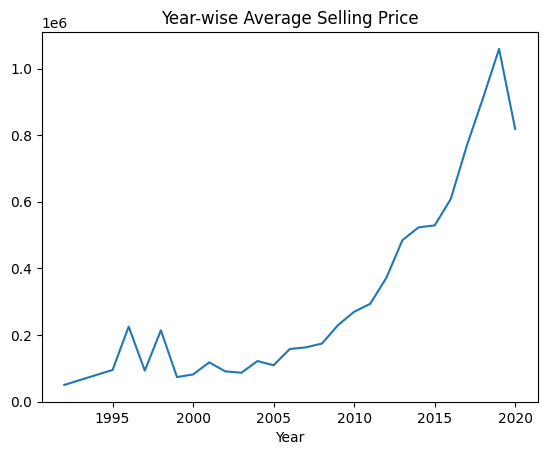

In [74]:
print(df.groupby("Year")["Selling Price"].mean())
df.groupby("Year")["Selling Price"].mean().plot(kind="line")
plt.title("Year-wise Average Selling Price")


## ✅ Transmission vs Price


C:\Users\SC\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


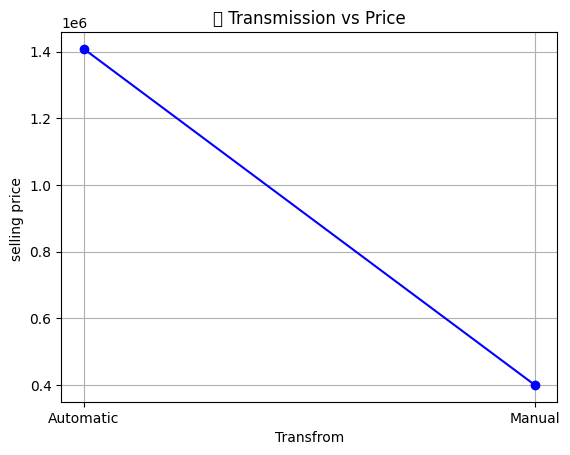

In [79]:

yearly_avg = df.groupby("Transminssion")["Selling Price"].mean()
x = yearly_avg.index
y = yearly_avg.values
plt.plot(x,y , marker = "o",color="b")
plt.title("✅ Transmission vs Price")
plt.xlabel("Transfrom")
plt.ylabel("selling price ")
plt.grid(True)
plt.show()
# Group by Transmission and get the mean Selling Price
# avg_price = df.groupby("Transminssion")["Selling Price"].mean().reset_index()

# # Bar plot
# plt.figure(figsize=(8, 6))
# sns.barplot(x="Transminssion", y="Selling Price", data=avg_price, palette="coolwarm")

# plt.title("Average Selling Price by Transmission Type")
# plt.xlabel("Transmission Type")
# plt.ylabel("Average Selling Price")
# plt.grid(True)
# plt.show()



### ✅ Seller Type vs Price


<Axes: xlabel='Seller Type', ylabel='Selling Price'>

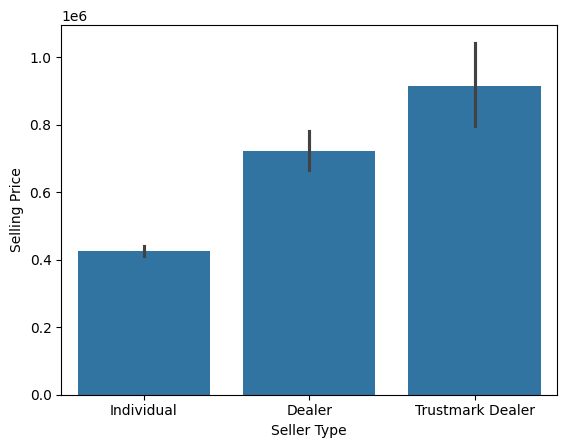

In [80]:
sns.barplot(x='Seller Type', y='Selling Price', data=df)


 ### ✅ Price vs KM driven with Fuel type


C:\Users\SC\AppData\Local\Temp\ipykernel_4704\4210571614.py:8: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='KM Range', y='Selling Price', hue='Fuel Type', data=df, ci=None)


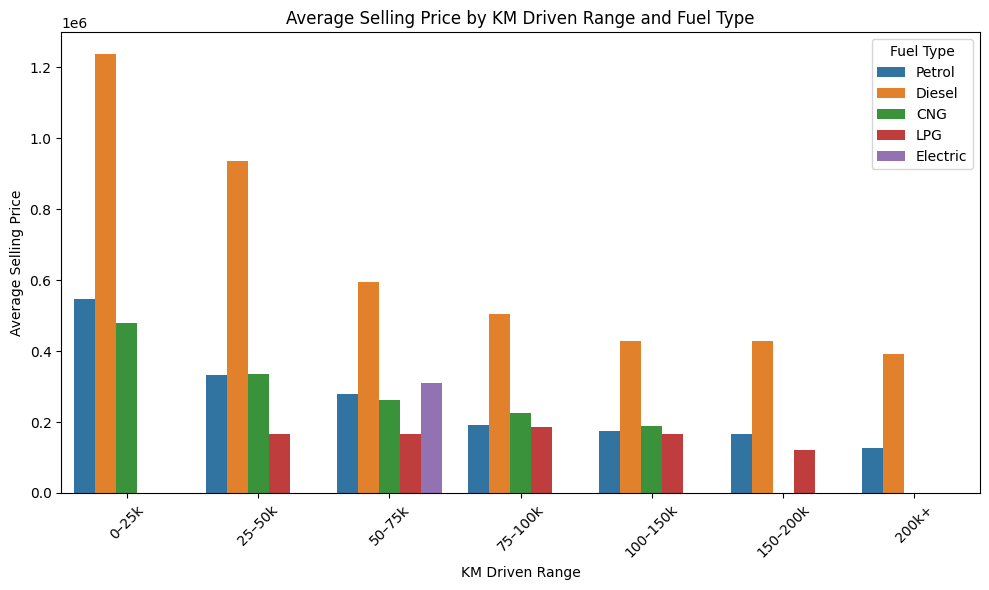

In [95]:
# sns.barplot(x='Kilometer Driven', y='Selling Price', hue='Fuel Type', data=df)
# Create distance bins
df['KM Range'] = pd.cut(df['Kilometer Driven'], bins=[0, 25000, 50000, 75000, 100000, 150000, 200000, 300000],
                        labels=['0–25k', '25–50k', '50–75k', '75–100k', '100–150k', '150–200k', '200k+'])

# Plot: KM Range vs Average Selling Price by Fuel Type
plt.figure(figsize=(10,6))
sns.barplot(x='KM Range', y='Selling Price', hue='Fuel Type', data=df, ci=None)
plt.title('Average Selling Price by KM Driven Range and Fuel Type')
plt.ylabel('Average Selling Price')
plt.xlabel('KM Driven Range')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## ✅ Car Age


In [97]:
df['Car Age'] = 2025 - df['Year']
df.head()

,Car Name,Year,Selling Price,Kilometer Driven,Fuel Type,Seller Type,Transminssion,Owner,KM Range,Car Age
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner,50–75k,18
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner,25–50k,18
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner,75–100k,13
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner,25–50k,8
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner,100–150k,11


## ✅ Price per KM


In [100]:
df['Price per KM'] = df['Selling Price'] / df['Kilometer Driven']
df

,Car Name,Year,Selling Price,Kilometer Driven,Fuel Type,Seller Type,Transminssion,Owner,KM Range,Car Age,Price per KM
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner,50–75k,18,0.857143
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner,25–50k,18,2.700000
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner,75–100k,13,6.000000
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner,25–50k,8,5.434783
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner,100–150k,11,3.191489
...,...,...,...,...,...,...,...,...,...,...,...
4335,Hyundai i20 Magna 1.4 CRDi (Diesel),2014,409999,80000,Diesel,Individual,Manual,Second Owner,75–100k,11,5.124987
4336,Hyundai i20 Magna 1.4 CRDi,2014,409999,80000,Diesel,Individual,Manual,Second Owner,75–100k,11,5.124987
4337,Maruti 800 AC BSIII,2009,110000,83000,Petrol,Individual,Manual,Second Owner,75–100k,16,1.325301
4338,Hyundai Creta 1.6 CRDi SX Option,2016,865000,90000,Diesel,Individual,Manual,First Owner,75–100k,9,9.611111


## ✅ New Feature: Is Old or New


In [105]:
df['Condition'] = df['Car Age'].apply(lambda x: 'New' if x < 10 else 'Old')
df

,Car Name,Year,Selling Price,Kilometer Driven,Fuel Type,Seller Type,Transminssion,Owner,KM Range,Car Age,Price per KM,Condition
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner,50–75k,18,0.857143,Old
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner,25–50k,18,2.700000,Old
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner,75–100k,13,6.000000,Old
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner,25–50k,8,5.434783,New
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner,100–150k,11,3.191489,Old
...,...,...,...,...,...,...,...,...,...,...,...,...
4335,Hyundai i20 Magna 1.4 CRDi (Diesel),2014,409999,80000,Diesel,Individual,Manual,Second Owner,75–100k,11,5.124987,Old
4336,Hyundai i20 Magna 1.4 CRDi,2014,409999,80000,Diesel,Individual,Manual,Second Owner,75–100k,11,5.124987,Old
4337,Maruti 800 AC BSIII,2009,110000,83000,Petrol,Individual,Manual,Second Owner,75–100k,16,1.325301,Old
4338,Hyundai Creta 1.6 CRDi SX Option,2016,865000,90000,Diesel,Individual,Manual,First Owner,75–100k,9,9.611111,New


🔹 6. Grouping and Aggregation


In [113]:
# ✅ Max & Min price by fuel type

df.groupby('Fuel Type')['Selling Price'].agg(['max', 'min', 'mean'])


,max,min,mean
Fuel Type,,,
CNG,595000,45000,277174.925000
Diesel,8150000,45000,669094.252206
Electric,310000,310000,310000.000000
LPG,290000,50000,167826.043478
Petrol,8900000,20000,344840.137541


### ✅ Top selling models by average price


In [107]:
df.groupby('Car Name')['Selling Price'].mean().sort_values(ascending=False).head(10)


Car Name
Audi RS7 2015-2019 Sportback Performance             8900000.0
Mercedes-Benz S-Class S 350d Connoisseurs Edition    8150000.0
Mercedes-Benz GLS 2016-2020 350d 4MATIC              5500000.0
BMW X5 xDrive 30d xLine                              4950000.0
Audi A5 Sportback                                    4700000.0
Mercedes-Benz E-Class Exclusive E 200 BSIV           4500000.0
Volvo XC 90 D5 Inscription BSIV                      4500000.0
Mercedes-Benz GL-Class 350 CDI Blue Efficiency       4400000.0
Land Rover Range Rover 4.4 Diesel LWB Vogue SE       4200000.0
Land Rover Discovery Sport TD4 HSE 7S                4000000.0
Name: Selling Price, dtype: float64

### ✅ Total cars per year


<Axes: title={'center': 'Cars by Year'}, xlabel='Year'>

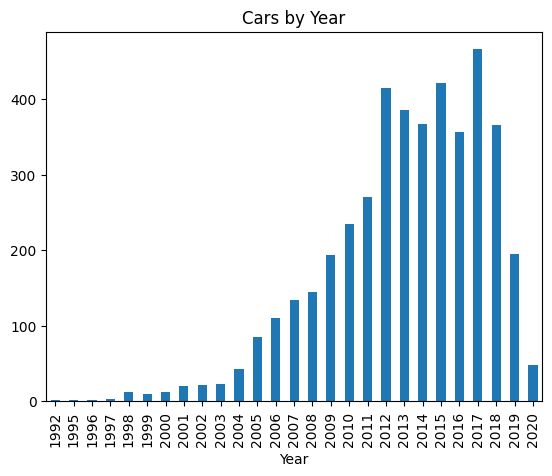

In [108]:
df['Year'].value_counts().sort_index().plot(kind='bar', title='Cars by Year')


🔹 7. Correlation Analysis


<Axes: >

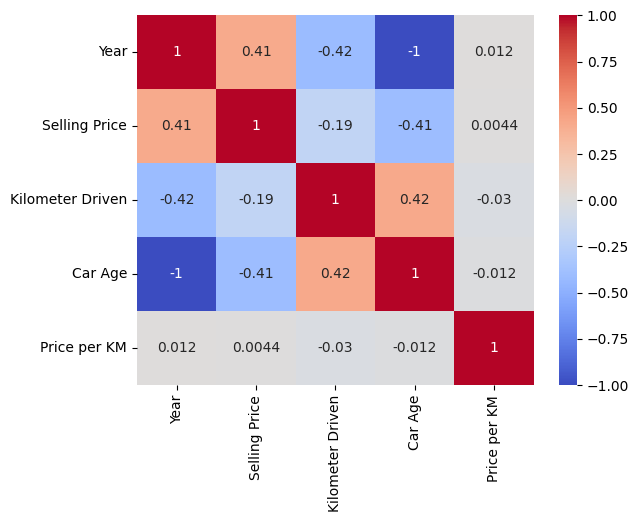

In [110]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')


🔹 8. Outlier Detection


<Axes: xlabel='Selling Price'>

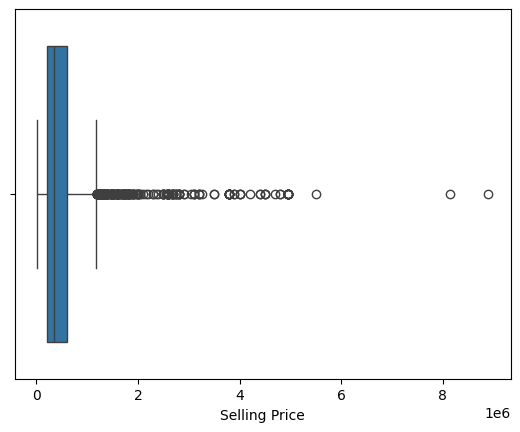

In [112]:
# ✅ Selling Price outliers

sns.boxplot(x=df['Selling Price'])


### ✅ KM driven outliers


<Axes: xlabel='Kilometer Driven'>

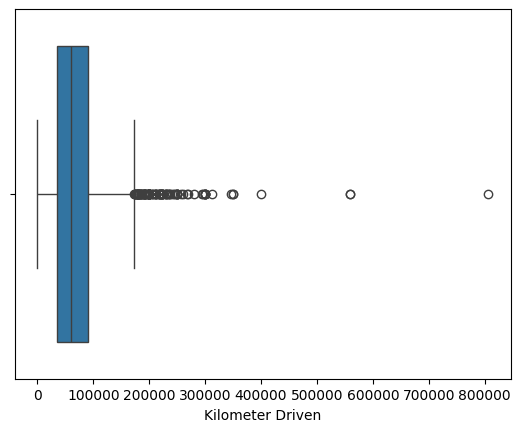

In [115]:
sns.boxplot(x=df['Kilometer Driven'])


# Advanced Ideas (optional but amazing)
### ✅ Distribution plots:

<Axes: xlabel='Selling Price', ylabel='Count'>

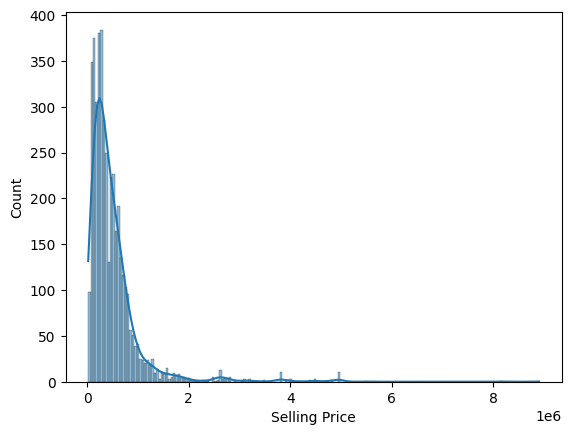

In [116]:
sns.histplot(df['Selling Price'], kde=True)


### ✅ Top 5 expensive cars


In [118]:
df.sort_values(by='Selling Price', ascending=False).head(5)


,Car Name,Year,Selling Price,Kilometer Driven,Fuel Type,Seller Type,Transminssion,Owner,KM Range,Car Age,Price per KM,Condition
3872,Audi RS7 2015-2019 Sportback Performance,2016,8900000,13000,Petrol,Dealer,Automatic,First Owner,0–25k,9,684.615385,New
89,Mercedes-Benz S-Class S 350d Connoisseurs Edition,2017,8150000,6500,Diesel,Dealer,Automatic,First Owner,0–25k,8,1253.846154,New
3969,Mercedes-Benz GLS 2016-2020 350d 4MATIC,2016,5500000,77350,Diesel,Dealer,Automatic,First Owner,75–100k,9,71.105365,New
2739,BMW X5 xDrive 30d xLine,2019,4950000,30000,Diesel,Dealer,Automatic,First Owner,25–50k,6,165.000000,New
612,BMW X5 xDrive 30d xLine,2019,4950000,30000,Diesel,Dealer,Automatic,First Owner,25–50k,6,165.000000,New


# 🔹 10. Export Results for Presentation


In [119]:
df.to_csv('analyzed_car_data.csv', index=False)
